# Predicting 10-Year Coronary Heart Disease Risk Using Machine Learning


****Predicting the risk of developing coronary heart disease (CHD) over a 10-year period can help in early intervention and prevention. This project uses the Framingham Heart Study dataset, which contains demographic, lifestyle, and medical features, to build predictive models.****

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# read the data

df = pd.read_csv("/kaggle/input/framingham-heart-study-dataset/framingham.csv")
df.head(10)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,0,43,2.0,0,0.0,0.0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0
6,0,63,1.0,0,0.0,0.0,0,0,0,205.0,138.0,71.0,33.11,60.0,85.0,1
7,0,45,2.0,1,20.0,0.0,0,0,0,313.0,100.0,71.0,21.68,79.0,78.0,0
8,1,52,1.0,0,0.0,0.0,0,1,0,260.0,141.5,89.0,26.36,76.0,79.0,0
9,1,43,1.0,1,30.0,0.0,0,1,0,225.0,162.0,107.0,23.61,93.0,88.0,0


# Exploratory Data Analysis
 

In [3]:
print(df.columns)
print("-------------------")
print(df.shape)
df.info()

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')
-------------------
(4240, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
male,4240.0,0.429245,0.495027,0.00,0.00,0.0,1.00,1.0
age,4240.0,49.580189,8.572942,32.00,42.00,49.0,56.00,70.0
education,4135.0,1.979444,1.019791,1.00,1.00,2.0,3.00,4.0
currentSmoker,4240.0,0.494104,0.500024,0.00,0.00,0.0,1.00,1.0
cigsPerDay,4211.0,9.005937,11.922462,0.00,0.00,0.0,20.00,70.0
BPMeds,4187.0,0.029615,0.169544,0.00,0.00,0.0,0.00,1.0
prevalentStroke,4240.0,0.005896,0.076569,0.00,0.00,0.0,0.00,1.0
prevalentHyp,4240.0,0.310613,0.462799,0.00,0.00,0.0,1.00,1.0
diabetes,4240.0,0.025708,0.158280,0.00,0.00,0.0,0.00,1.0
totChol,4190.0,236.699523,44.591284,107.00,206.00,234.0,263.00,696.0


In [5]:
for col in df.columns:
    print(col, ":", df[col].nunique())


male : 2
age : 39
education : 4
currentSmoker : 2
cigsPerDay : 33
BPMeds : 2
prevalentStroke : 2
prevalentHyp : 2
diabetes : 2
totChol : 248
sysBP : 234
diaBP : 146
BMI : 1364
heartRate : 73
glucose : 143
TenYearCHD : 2


In [6]:
df.isnull().sum()


male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

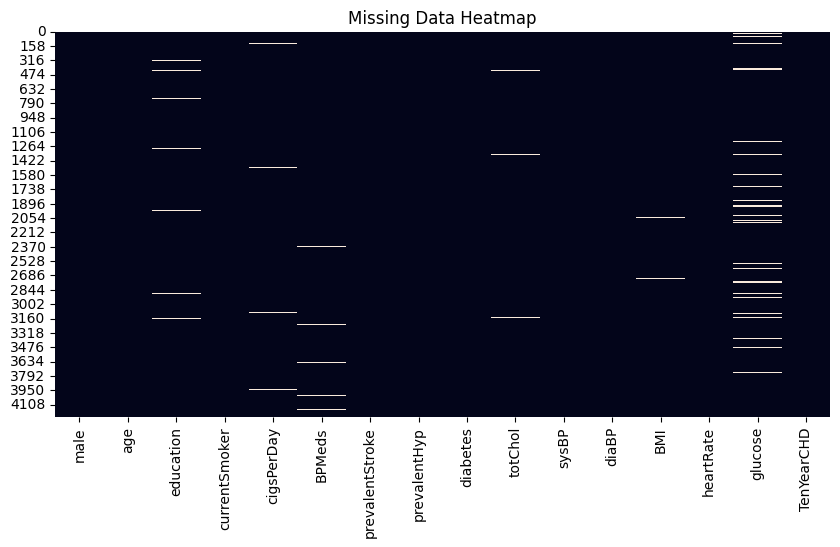

In [7]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data Heatmap")
plt.show()


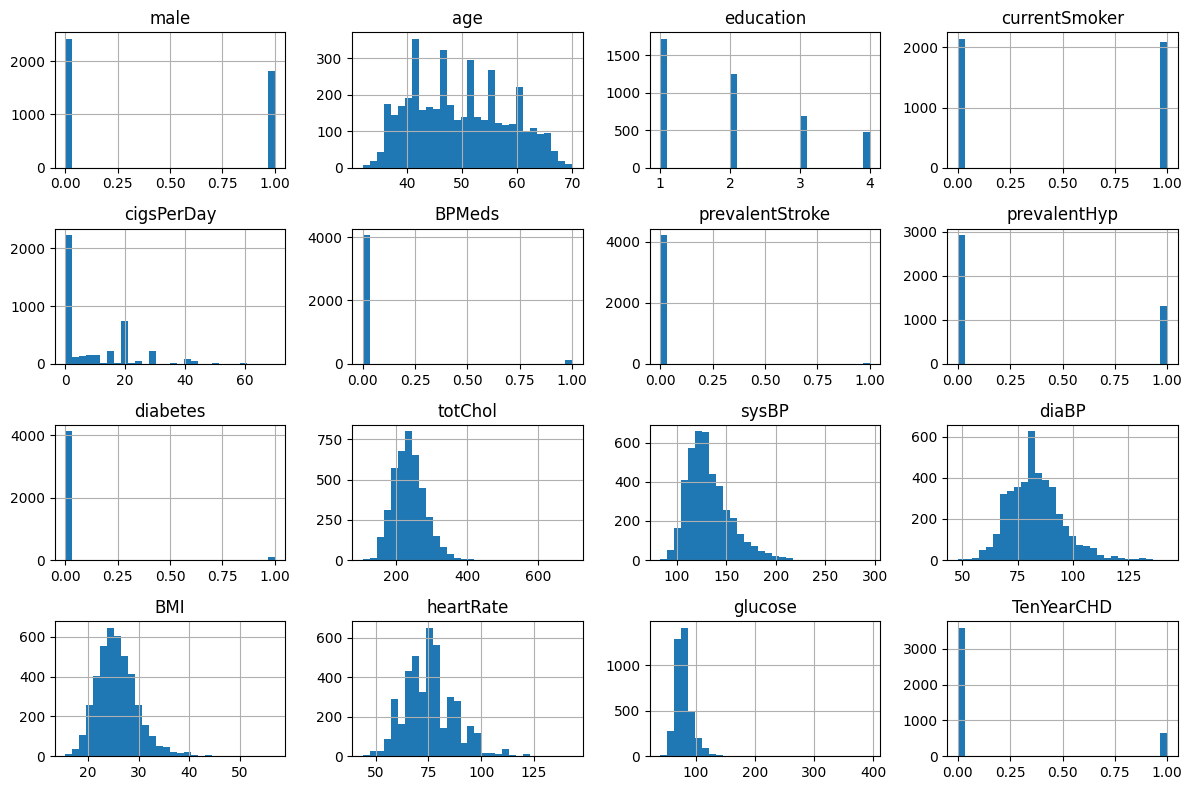

In [8]:
df.hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()


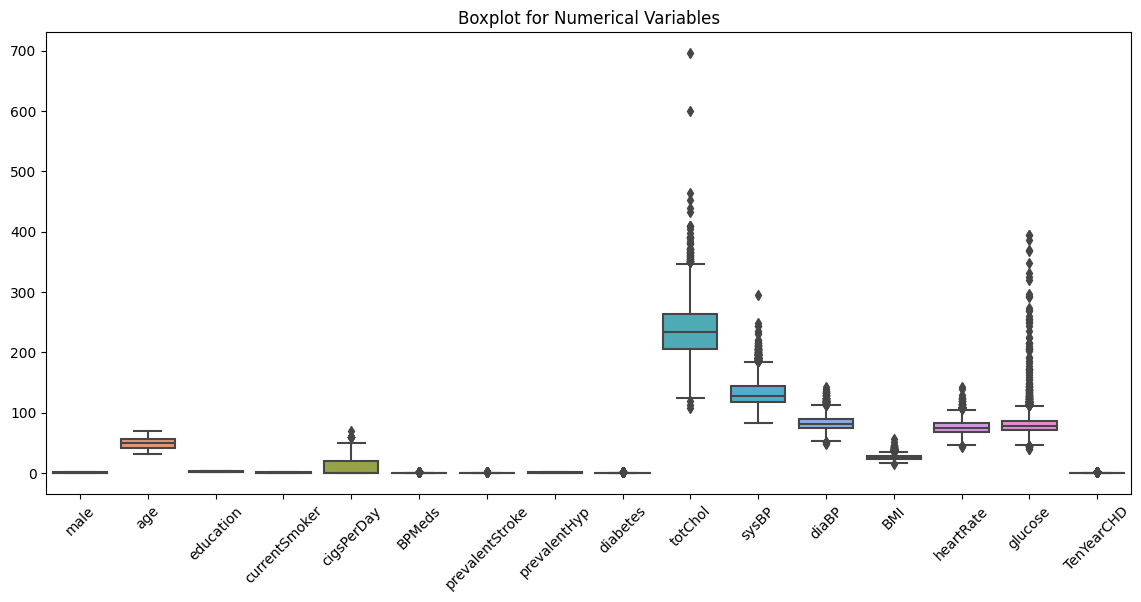

In [9]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot for Numerical Variables")
plt.show()


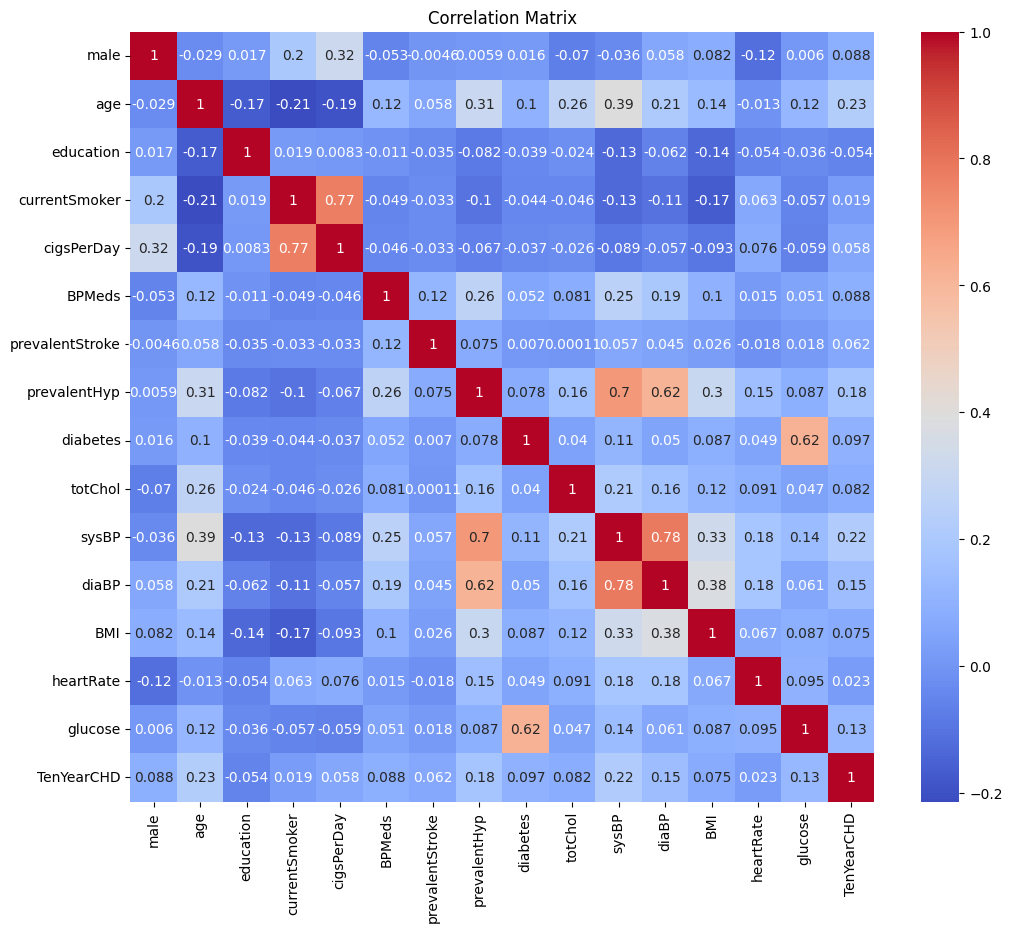

In [10]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


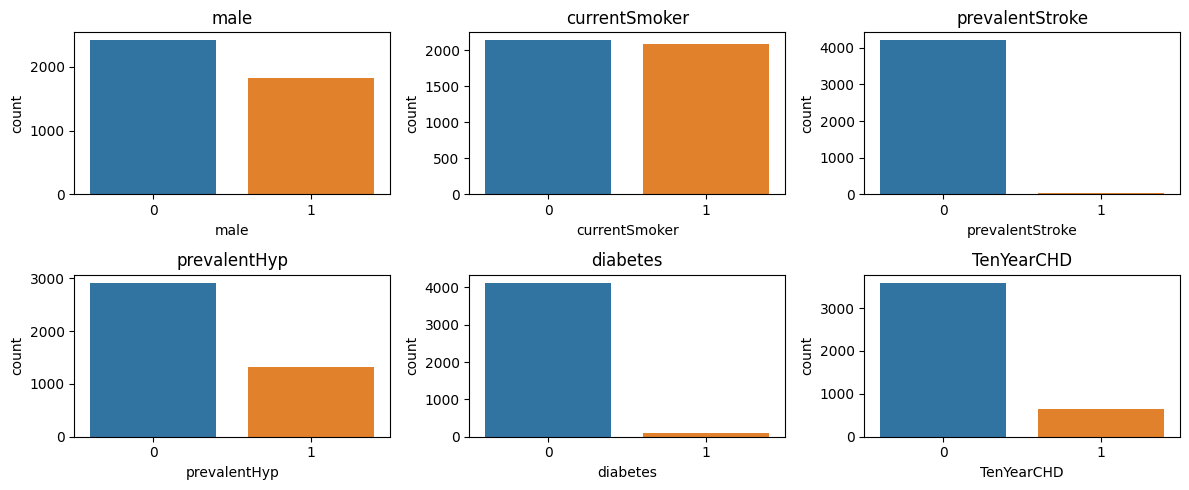

In [11]:
bin_cols = ['male','currentSmoker','prevalentStroke','prevalentHyp','diabetes','TenYearCHD']

plt.figure(figsize=(12,5))
for i, col in enumerate(bin_cols):
    plt.subplot(2, 3, i+1)
    sns.countplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


In [12]:
df['TenYearCHD'].value_counts(), df['TenYearCHD'].value_counts(normalize=True)*100


(TenYearCHD
 0    3596
 1     644
 Name: count, dtype: int64,
 TenYearCHD
 0    84.811321
 1    15.188679
 Name: proportion, dtype: float64)

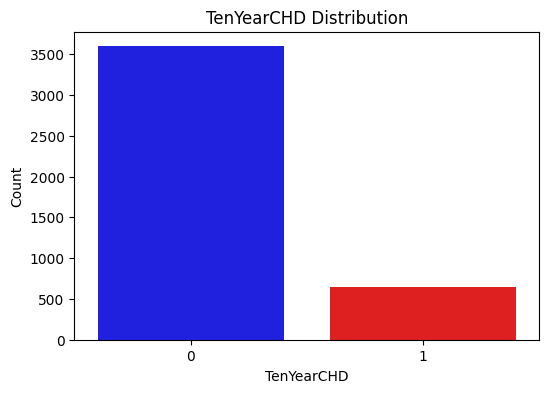

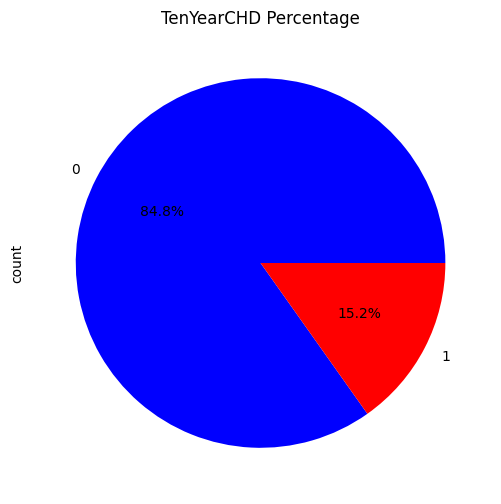

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='TenYearCHD', palette={0:'blue', 1:'red'})
plt.title('TenYearCHD Distribution')
plt.xlabel('TenYearCHD')
plt.ylabel('Count')
plt.show()


colors = ['blue', 'red']  

df['TenYearCHD'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', figsize=(6,6), colors=colors
)
plt.title('TenYearCHD Percentage')
plt.show()

# Preprocessing the data

In [14]:
#Handle missing values
# Continuous Features
continuous_cols = ['cigsPerDay','totChol','BMI','heartRate','glucose']

for col in continuous_cols:
    df[col] = df[col].fillna(df[col].median())



# Categorical / Binary Features
categorical_cols = ['education','BPMeds']

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    

df.isnull().sum()


male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

In [15]:
#discover the outliers
numerical_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if df[col].nunique() > 1]  

outlier_summary = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    count = len(outliers)
    pct = (count / len(df)) * 100
    outlier_summary.append({'Feature': col, 'Outliers Count': count, 'Outliers %': pct})

outlier_df = pd.DataFrame(outlier_summary).sort_values(by='Outliers %', ascending=False)
outlier_df


,Feature,Outliers Count,Outliers %
15,TenYearCHD,644,15.188679
14,glucose,262,6.179245
10,sysBP,126,2.971698
5,BPMeds,124,2.924528
8,diabetes,109,2.570755
12,BMI,97,2.287736
11,diaBP,77,1.816038
13,heartRate,76,1.792453
9,totChol,57,1.344340
6,prevalentStroke,25,0.589623


In [16]:
#handle the outliers in the continous_clos
continuous_cols = ['glucose','sysBP','diaBP','BMI','heartRate','totChol','cigsPerDay']


for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])


In [17]:
# StandardScaler forـ continuous features

# Binary / Categorical Features
#binary_cols = ['male','currentSmoker','prevalentStroke','prevalentHyp','diabetes','BPMeds']



# Continuous Features
continuous_cols = ['age','cigsPerDay','totChol','sysBP','diaBP','BMI','heartRate','glucose']


df_scaled = df.copy()


scaler = StandardScaler()
df_scaled[continuous_cols] = scaler.fit_transform(df_scaled[continuous_cols])


df_scaled.head()
#df_scaled.info()


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,-1.234283,4.0,0,-0.756544,0.0,0,0,0,-0.973421,-1.255579,-1.117476,0.331589,0.365659,-0.213981,0
1,0,-0.417664,2.0,0,-0.756544,0.0,0,0,0,0.326994,-0.528850,-0.152853,0.796271,1.656437,-0.301304,0
2,1,-0.184345,1.0,1,0.940946,0.0,0,0,0,0.208775,-0.213934,-0.240546,-0.098771,-0.064600,-0.825238,0
3,0,1.332233,3.0,1,1.789690,0.0,0,1,0,-0.264104,0.876160,1.074850,0.756668,-0.925118,2.056403,1
4,0,-0.417664,3.0,1,1.195569,0.0,0,0,0,1.154531,-0.092812,0.110226,-0.690185,0.795919,0.484598,0


In [18]:
X = df_scaled.drop("TenYearCHD", axis=1)

y = df_scaled["TenYearCHD"]


X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))


X_train shape: (3392, 15)
X_test shape: (848, 15)
y_train distribution:
 TenYearCHD
0    0.848172
1    0.151828
Name: proportion, dtype: float64
y_test distribution:
 TenYearCHD
0    0.847877
1    0.152123
Name: proportion, dtype: float64


# LogisticRegression

Accuracy: 0.847877358490566

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.99      0.92       719
           1       0.50      0.05      0.10       129

    accuracy                           0.85       848
   macro avg       0.68      0.52      0.51       848
weighted avg       0.80      0.85      0.79       848


Confusion Matrix:
 [[712   7]
 [122   7]]


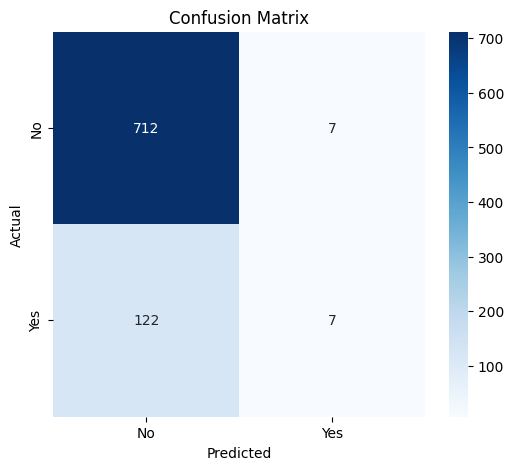

In [19]:
log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# XGBoost Classifier

Accuracy: 0.847877358490566

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.99      0.92       719
           1       0.50      0.07      0.12       129

    accuracy                           0.85       848
   macro avg       0.68      0.53      0.52       848
weighted avg       0.80      0.85      0.80       848


Confusion Matrix:
 [[710   9]
 [120   9]]


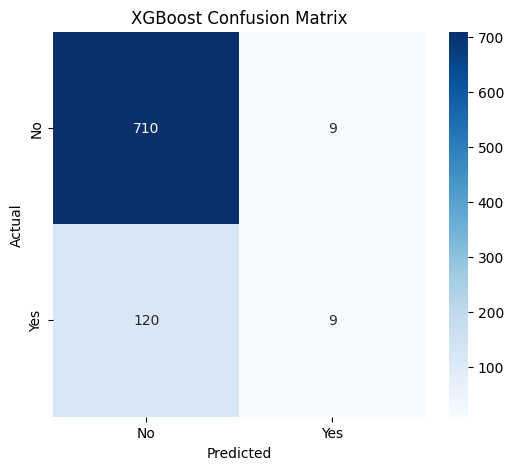

In [20]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    random_state=42,
    eval_metric='logloss'
)



xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))



cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')
plt.show()

# MLP Classifier (Neural Network)

Accuracy: 0.8018867924528302

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.91      0.89       719
           1       0.28      0.19      0.22       129

    accuracy                           0.80       848
   macro avg       0.57      0.55      0.55       848
weighted avg       0.77      0.80      0.79       848



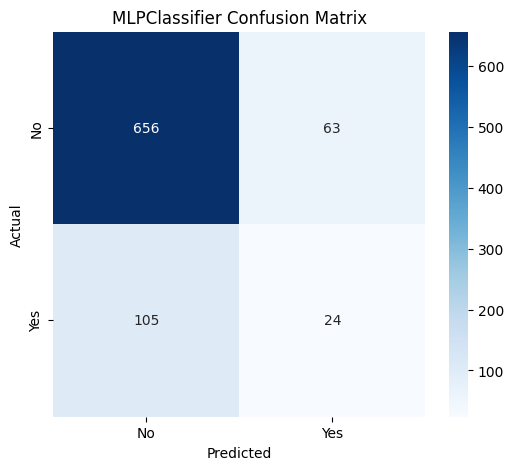

In [21]:

mlp_model = MLPClassifier(
    hidden_layer_sizes=(128,128,32, 16),  
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42)

mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print("\nClassification Report:\n", classification_report(y_test, y_pred_mlp))



cm = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('MLPClassifier Confusion Matrix')
plt.show()


# Conclusion



**The goal of this project was to build a predictive model for 10-year coronary heart disease (CHD) risk using machine learning techniques. After performing exploratory data analysis and data preprocessing, several classification models were trained and evaluated.**

**Logistic Regression and XGBoost achieved the best overall performance, reaching an accuracy of around 85%. The MLP Classifier achieved an accuracy of 80%, but with a higher recall for CHD = Yes (19%), which is better than both Logistic Regression and XGBoost for detecting positive cases.**